# Feature Selection

In [86]:
import pandas as pd
import numpy as np
from src.common.utils import get_root_directory
from src.common.stats import grangers_causality_test
from src.common.plotter import Plotter
import matplotlib.pyplot as plt
import numpy as np
from src.preprocessing.data_loader import DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import mlflow
import mlflow.sklearn
import shap
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import f_regression, SelectKBest, mutual_info_regression, RFE,SequentialFeatureSelector
from sklearn.linear_model import Lasso

In [61]:
root_dir = get_root_directory()
plotter = Plotter(root_dir)
DL = DataLoader(root_dir)
DL.load_data()
# publishers = ['Cointelegraph', 'CoinDesk', 'CoinGape', 'Cointelegraph Deutschland', 'U.Today','The Block', 'Decrypt', 'Cointelegraph Brasil', 'Blockworks','br.cointelegraph.com']
DL.merge_selected_data(selected_data=['BTC','LTC','sentiment_analysis'])
DL.final_data.columns

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol',
       'BTC_D_AvgPrc', 'BTC_YF_Op', 'BTC_YF_Hi', 'BTC_YF_Lo', 'BTC_YF_Cls',
       'BTC_YF_Vol', 'BTC_OL_MktCap', 'BTC_OL_BlkSz', 'BTC_OL_AvgComPwr',
       'BTC_OL_AvgTransFee', 'BTC_OL_MinDif', 'BTC_OL_ActAdd', 'BTC_OL_NewAdd',
       'BTC_OL_ChnTrans', 'BTC_OL_ChnVol', 'BTC_BIC_HshRt', 'LTC_D_AvgPrc',
       'LTC_YF_Op', 'LTC_YF_Hi', 'LTC_YF_Lo', 'LTC_YF_Cls', 'LTC_YF_Vol',
       'LTC_OL_MktCap', 'LTC_OL_BlkSz', 'LTC_OL_AvgComPwr',
       'LTC_OL_AvgTransFee', 'LTC_OL_MinDif', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd',
       'LTC_OL_ChnTrans', 'LTC_BIC_HshRt', 'D_VADER_AvgScr_In',
       'D_VADER_Sent_AvgIn', 'D_VADE

### Filter Methods

In [62]:
n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"
split_size = 0.15

In [63]:
selected_features = ['ETH_D_AvgPrc', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
                     'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
                     'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
                     'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol','BTC_D_AvgPrc',
                     'BTC_YF_Vol', 'BTC_OL_BlkSz', 'BTC_OL_AvgComPwr','BTC_OL_AvgTransFee',
                     'BTC_OL_MinDif', 'BTC_OL_ActAdd', 'BTC_OL_NewAdd','BTC_OL_ChnTrans',
                     'BTC_OL_ChnVol', 'BTC_BIC_HshRt', 'LTC_D_AvgPrc','LTC_OL_BlkSz', 'LTC_OL_AvgComPwr',
                     'LTC_OL_AvgTransFee', 'LTC_OL_MinDif', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd','LTC_OL_ChnTrans',
                     'LTC_BIC_HshRt', 'D_VADER_AvgScr_In','D_VADER_AvgScr_Ex','D_FINBERT_AvgScr_In',
                     'D_FINBERT_AvgScr_Ex','D_CRYPTOBERT_AvgScr_In','D_CRYPTOBERT_AvgScr_Ex']
DL.select_features(features=selected_features)
DL.set_time_range(start_date=start_date, end_date=end_date)

### Pearson

#### With All publishers

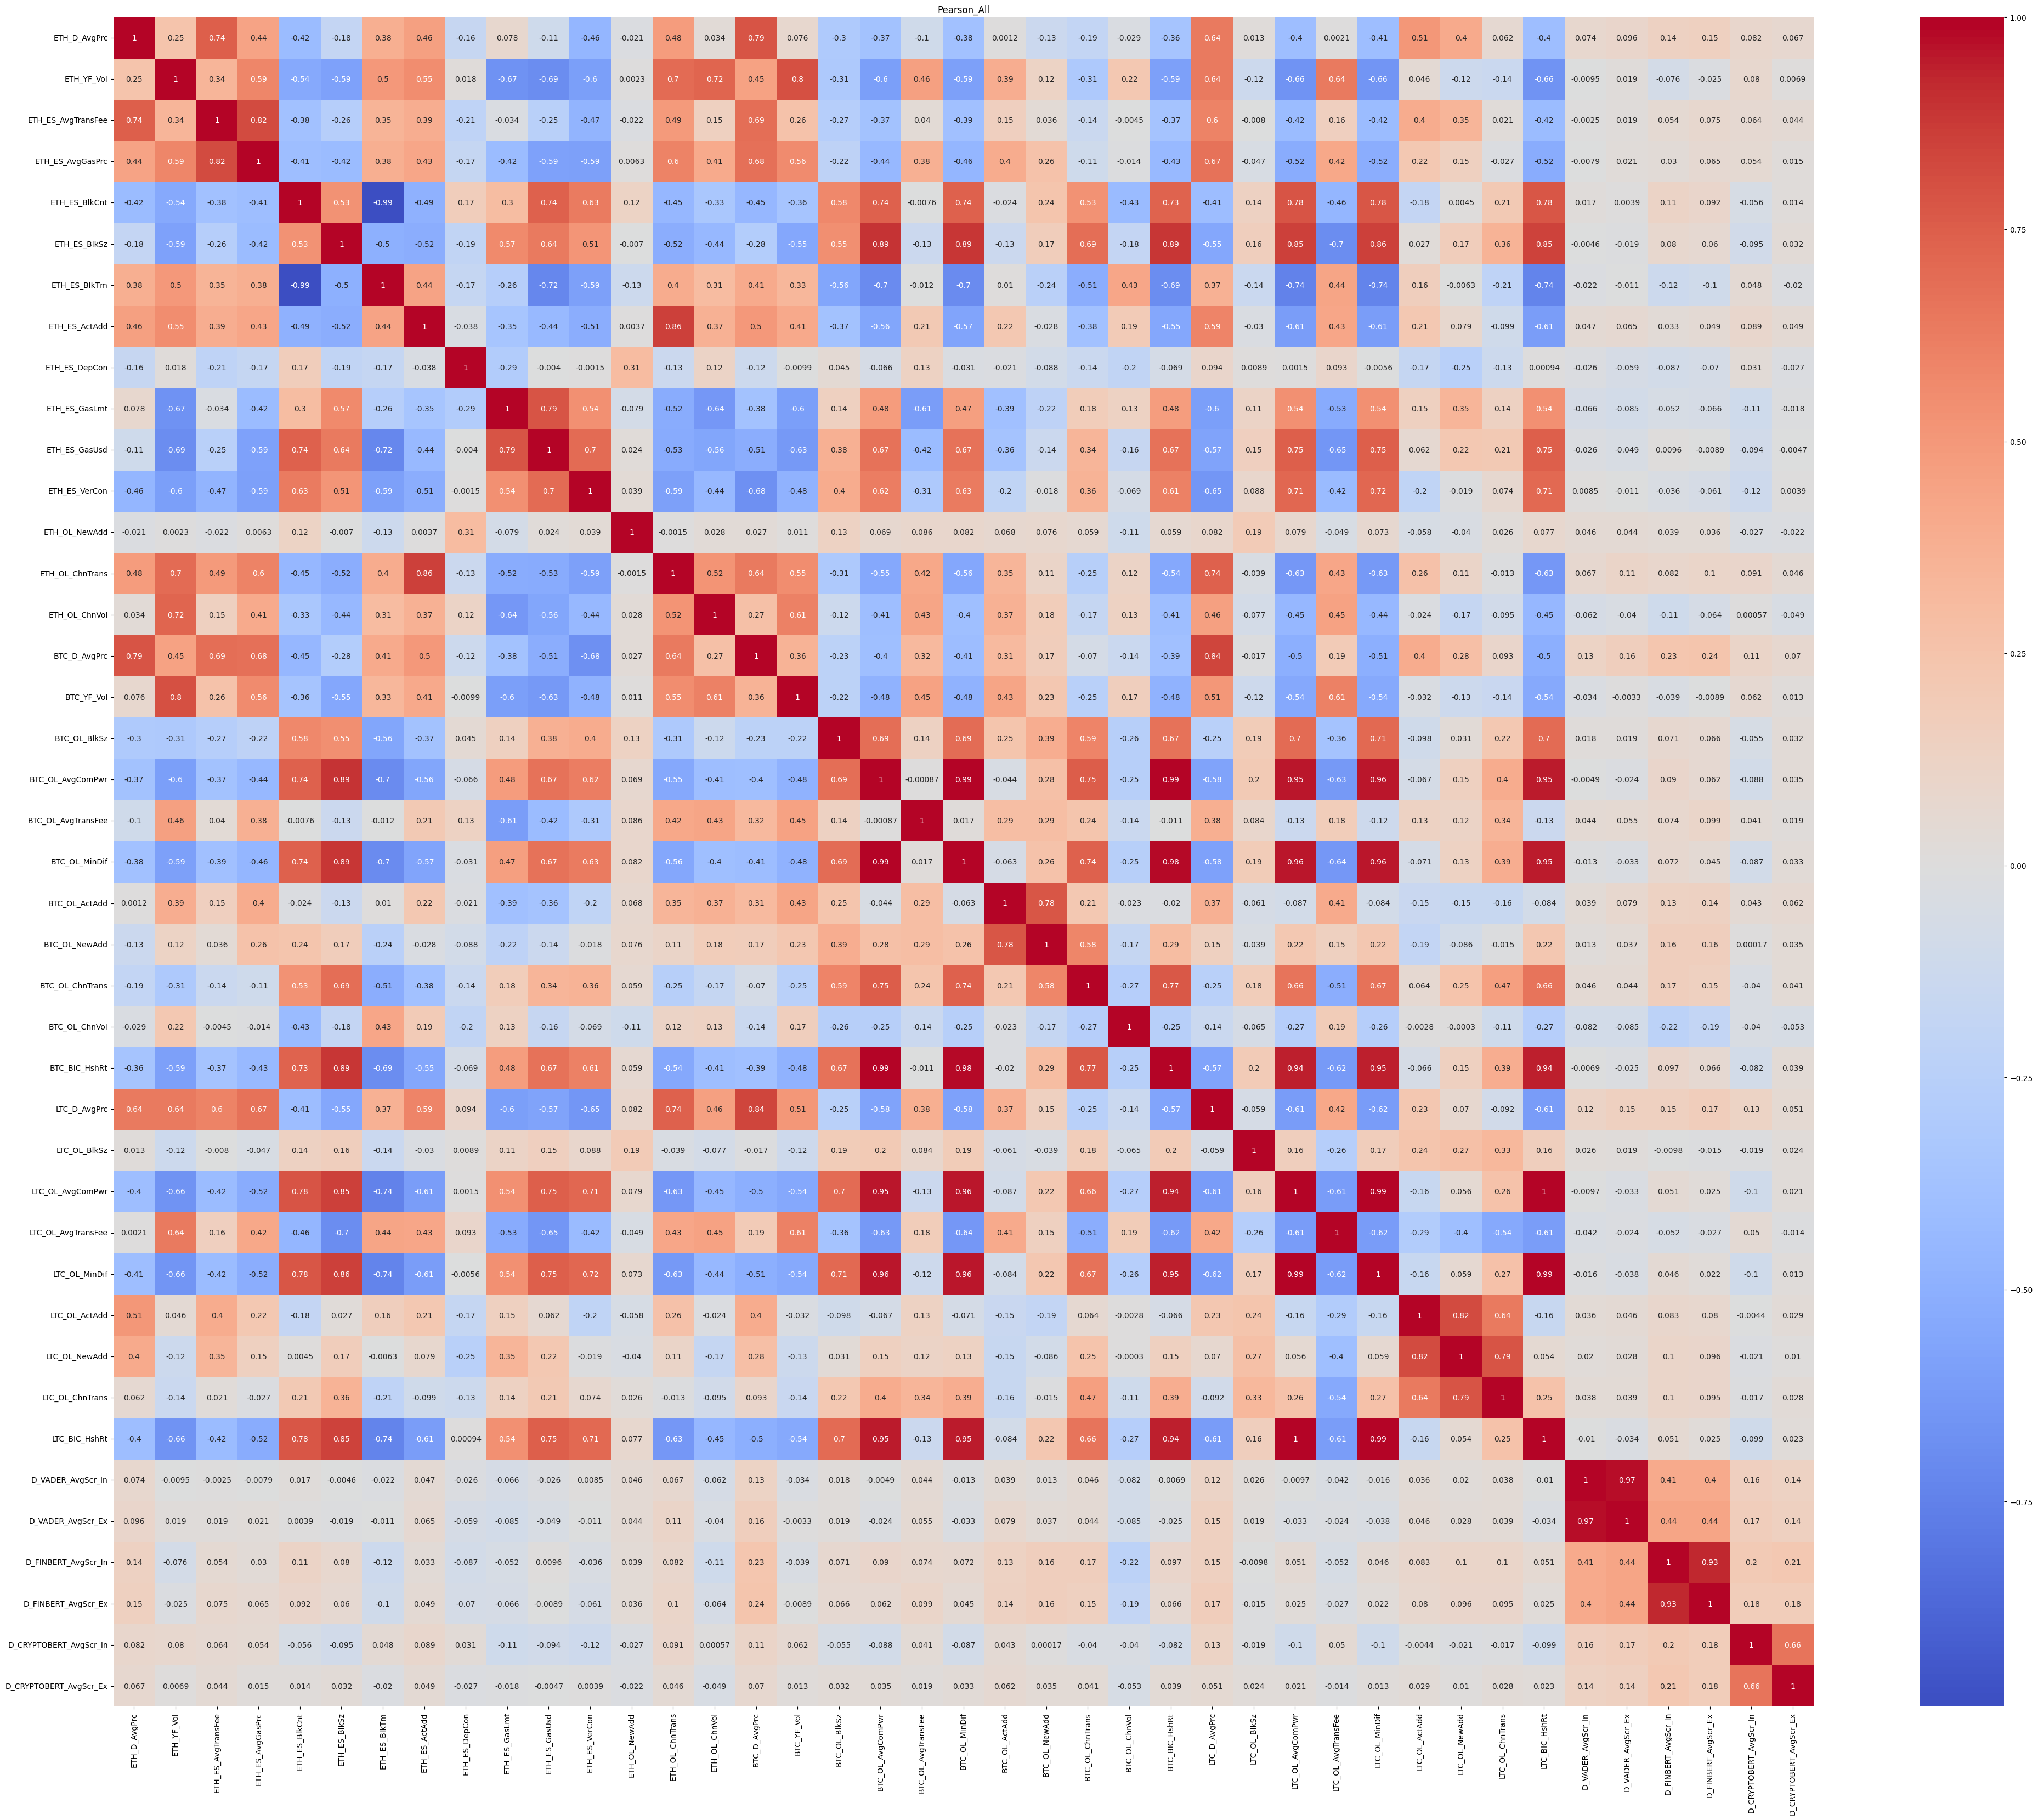

In [11]:
plotter.plot_correlation_matrix(DL.final_data, method="pearson", figsize=(50,40), title="Pearson_ALL")

In [12]:
plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\correlation_matrix")

#### With Selected publishers

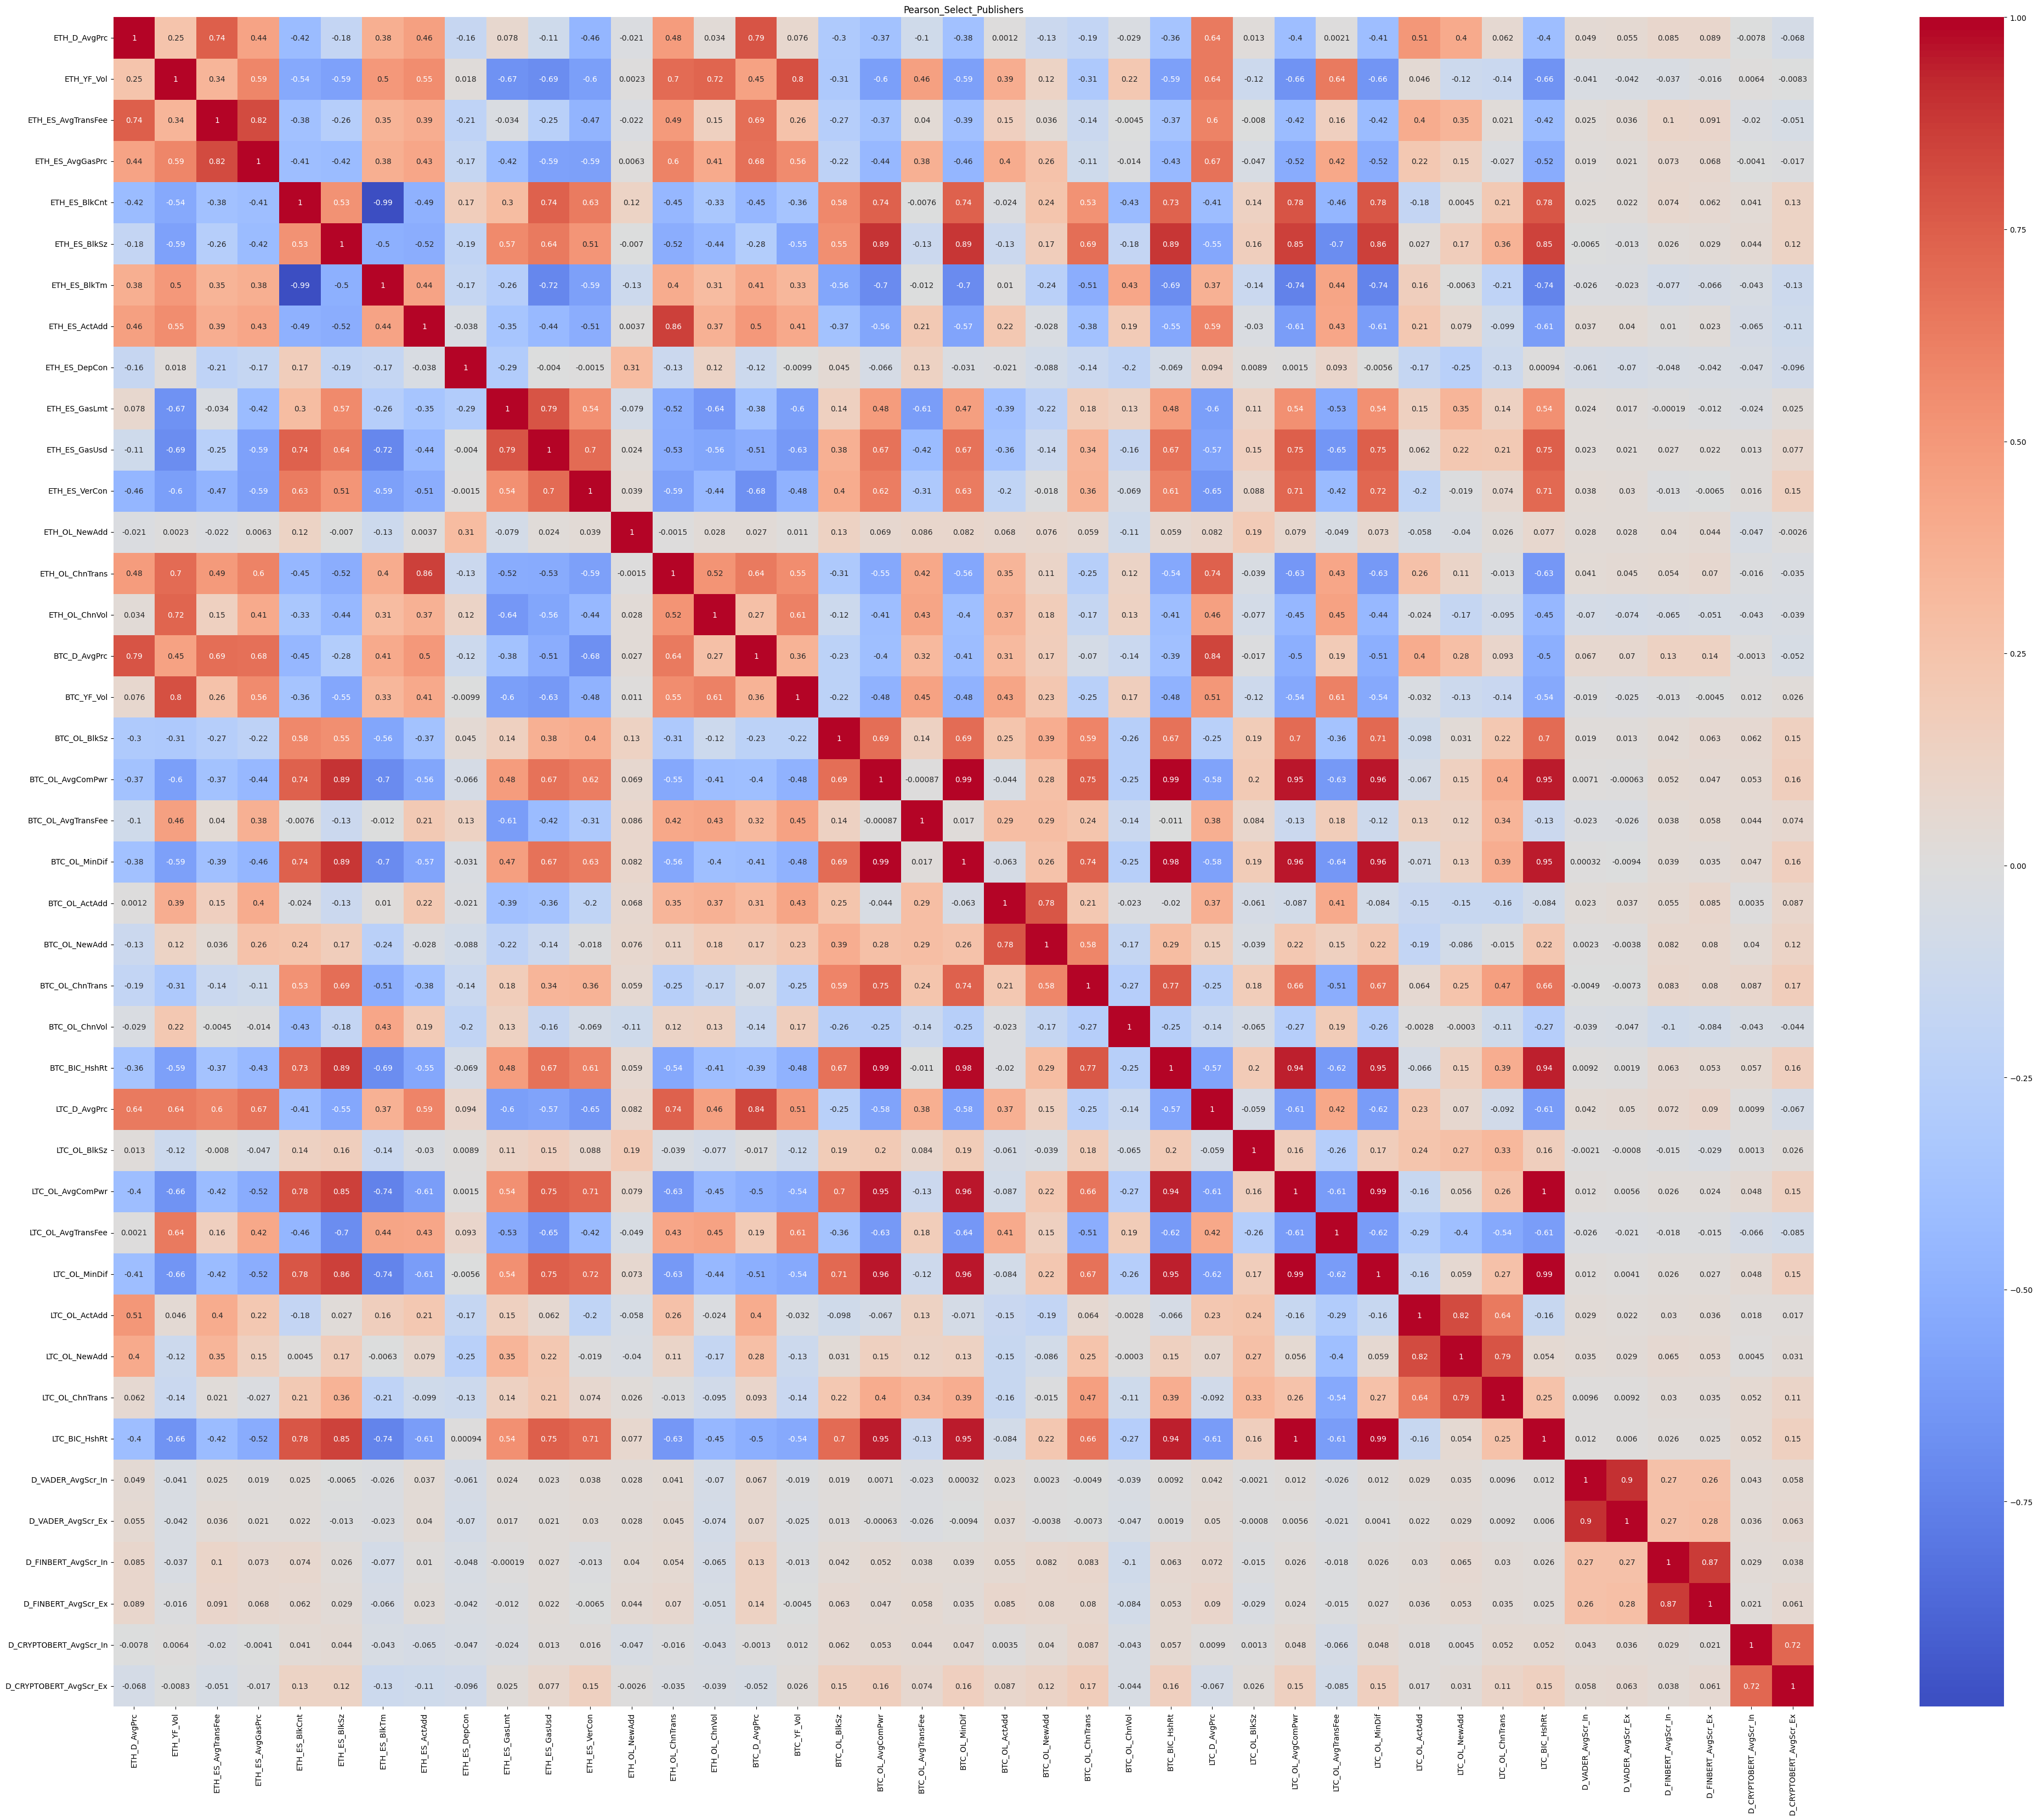

In [18]:
plotter.plot_correlation_matrix(DL.final_data, method="pearson", figsize=(50,40), title="Pearson_Select_Publishers")

In [19]:
plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\correlation_matrix")

### Spearman

#### With All publishers

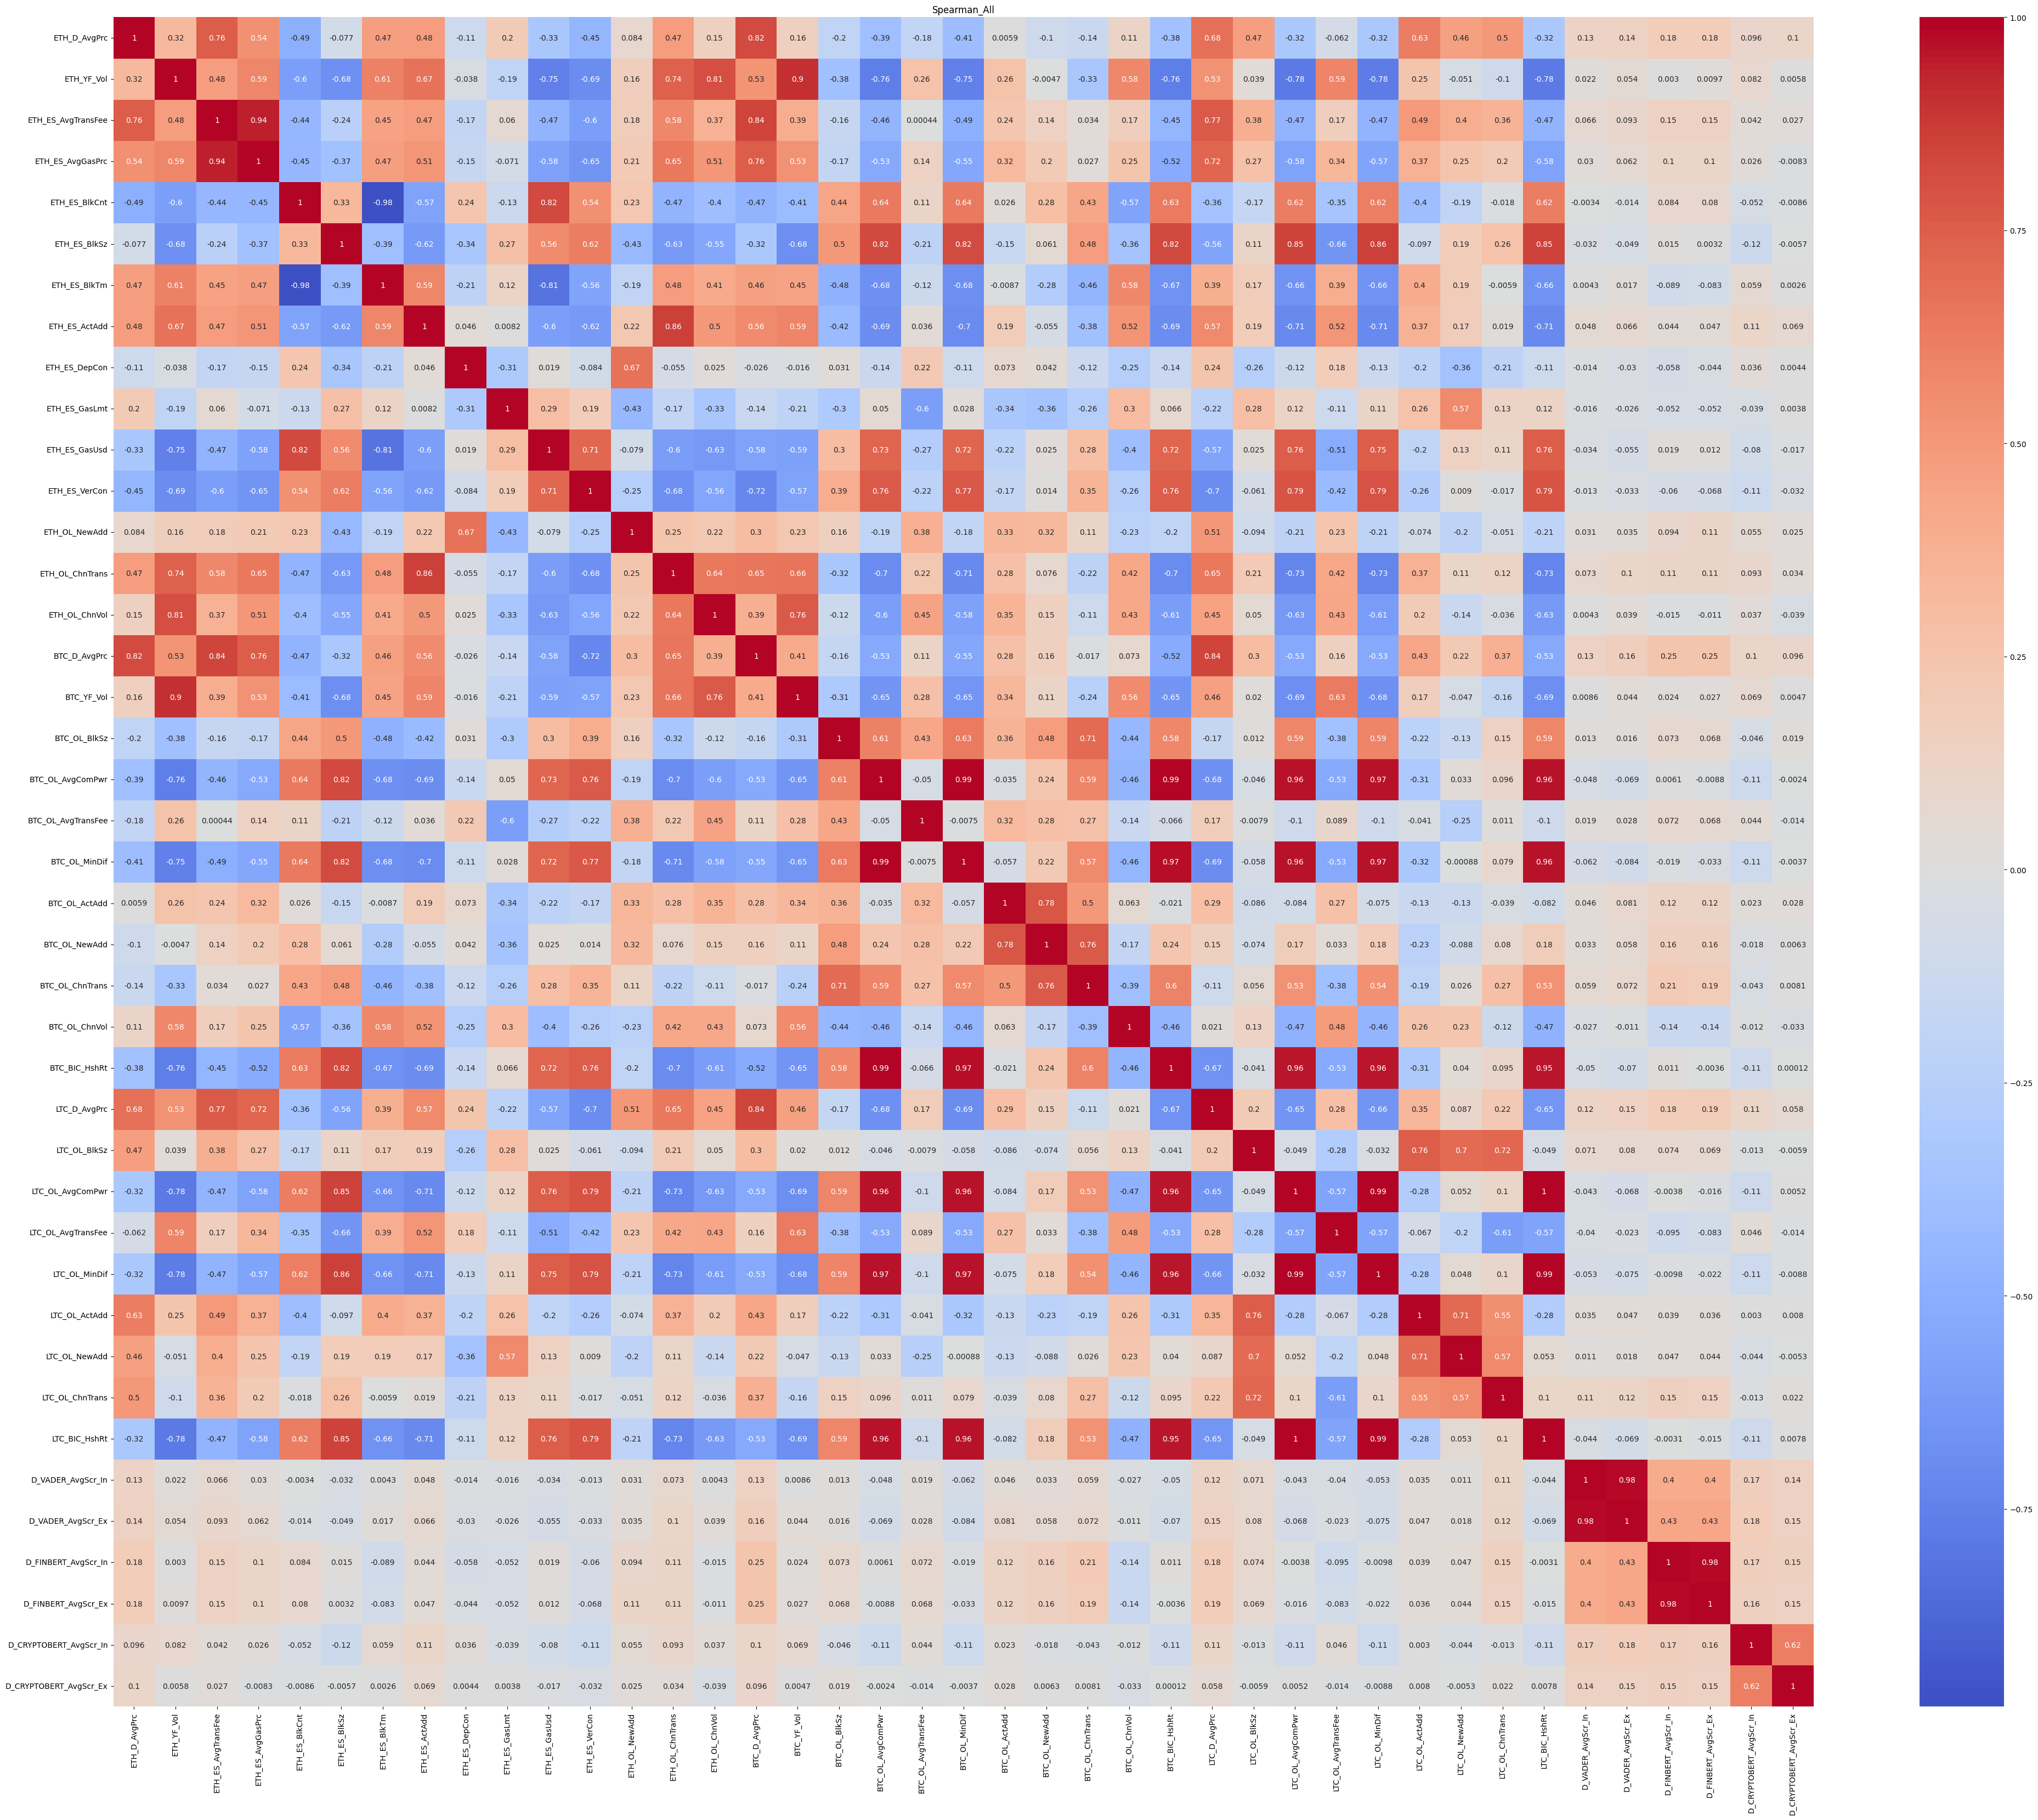

In [13]:
plotter.plot_correlation_matrix(DL.final_data, method="spearman", figsize=(50,40), title="Spearman_ALL")

In [14]:
plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\correlation_matrix")

#### With Selected publishers

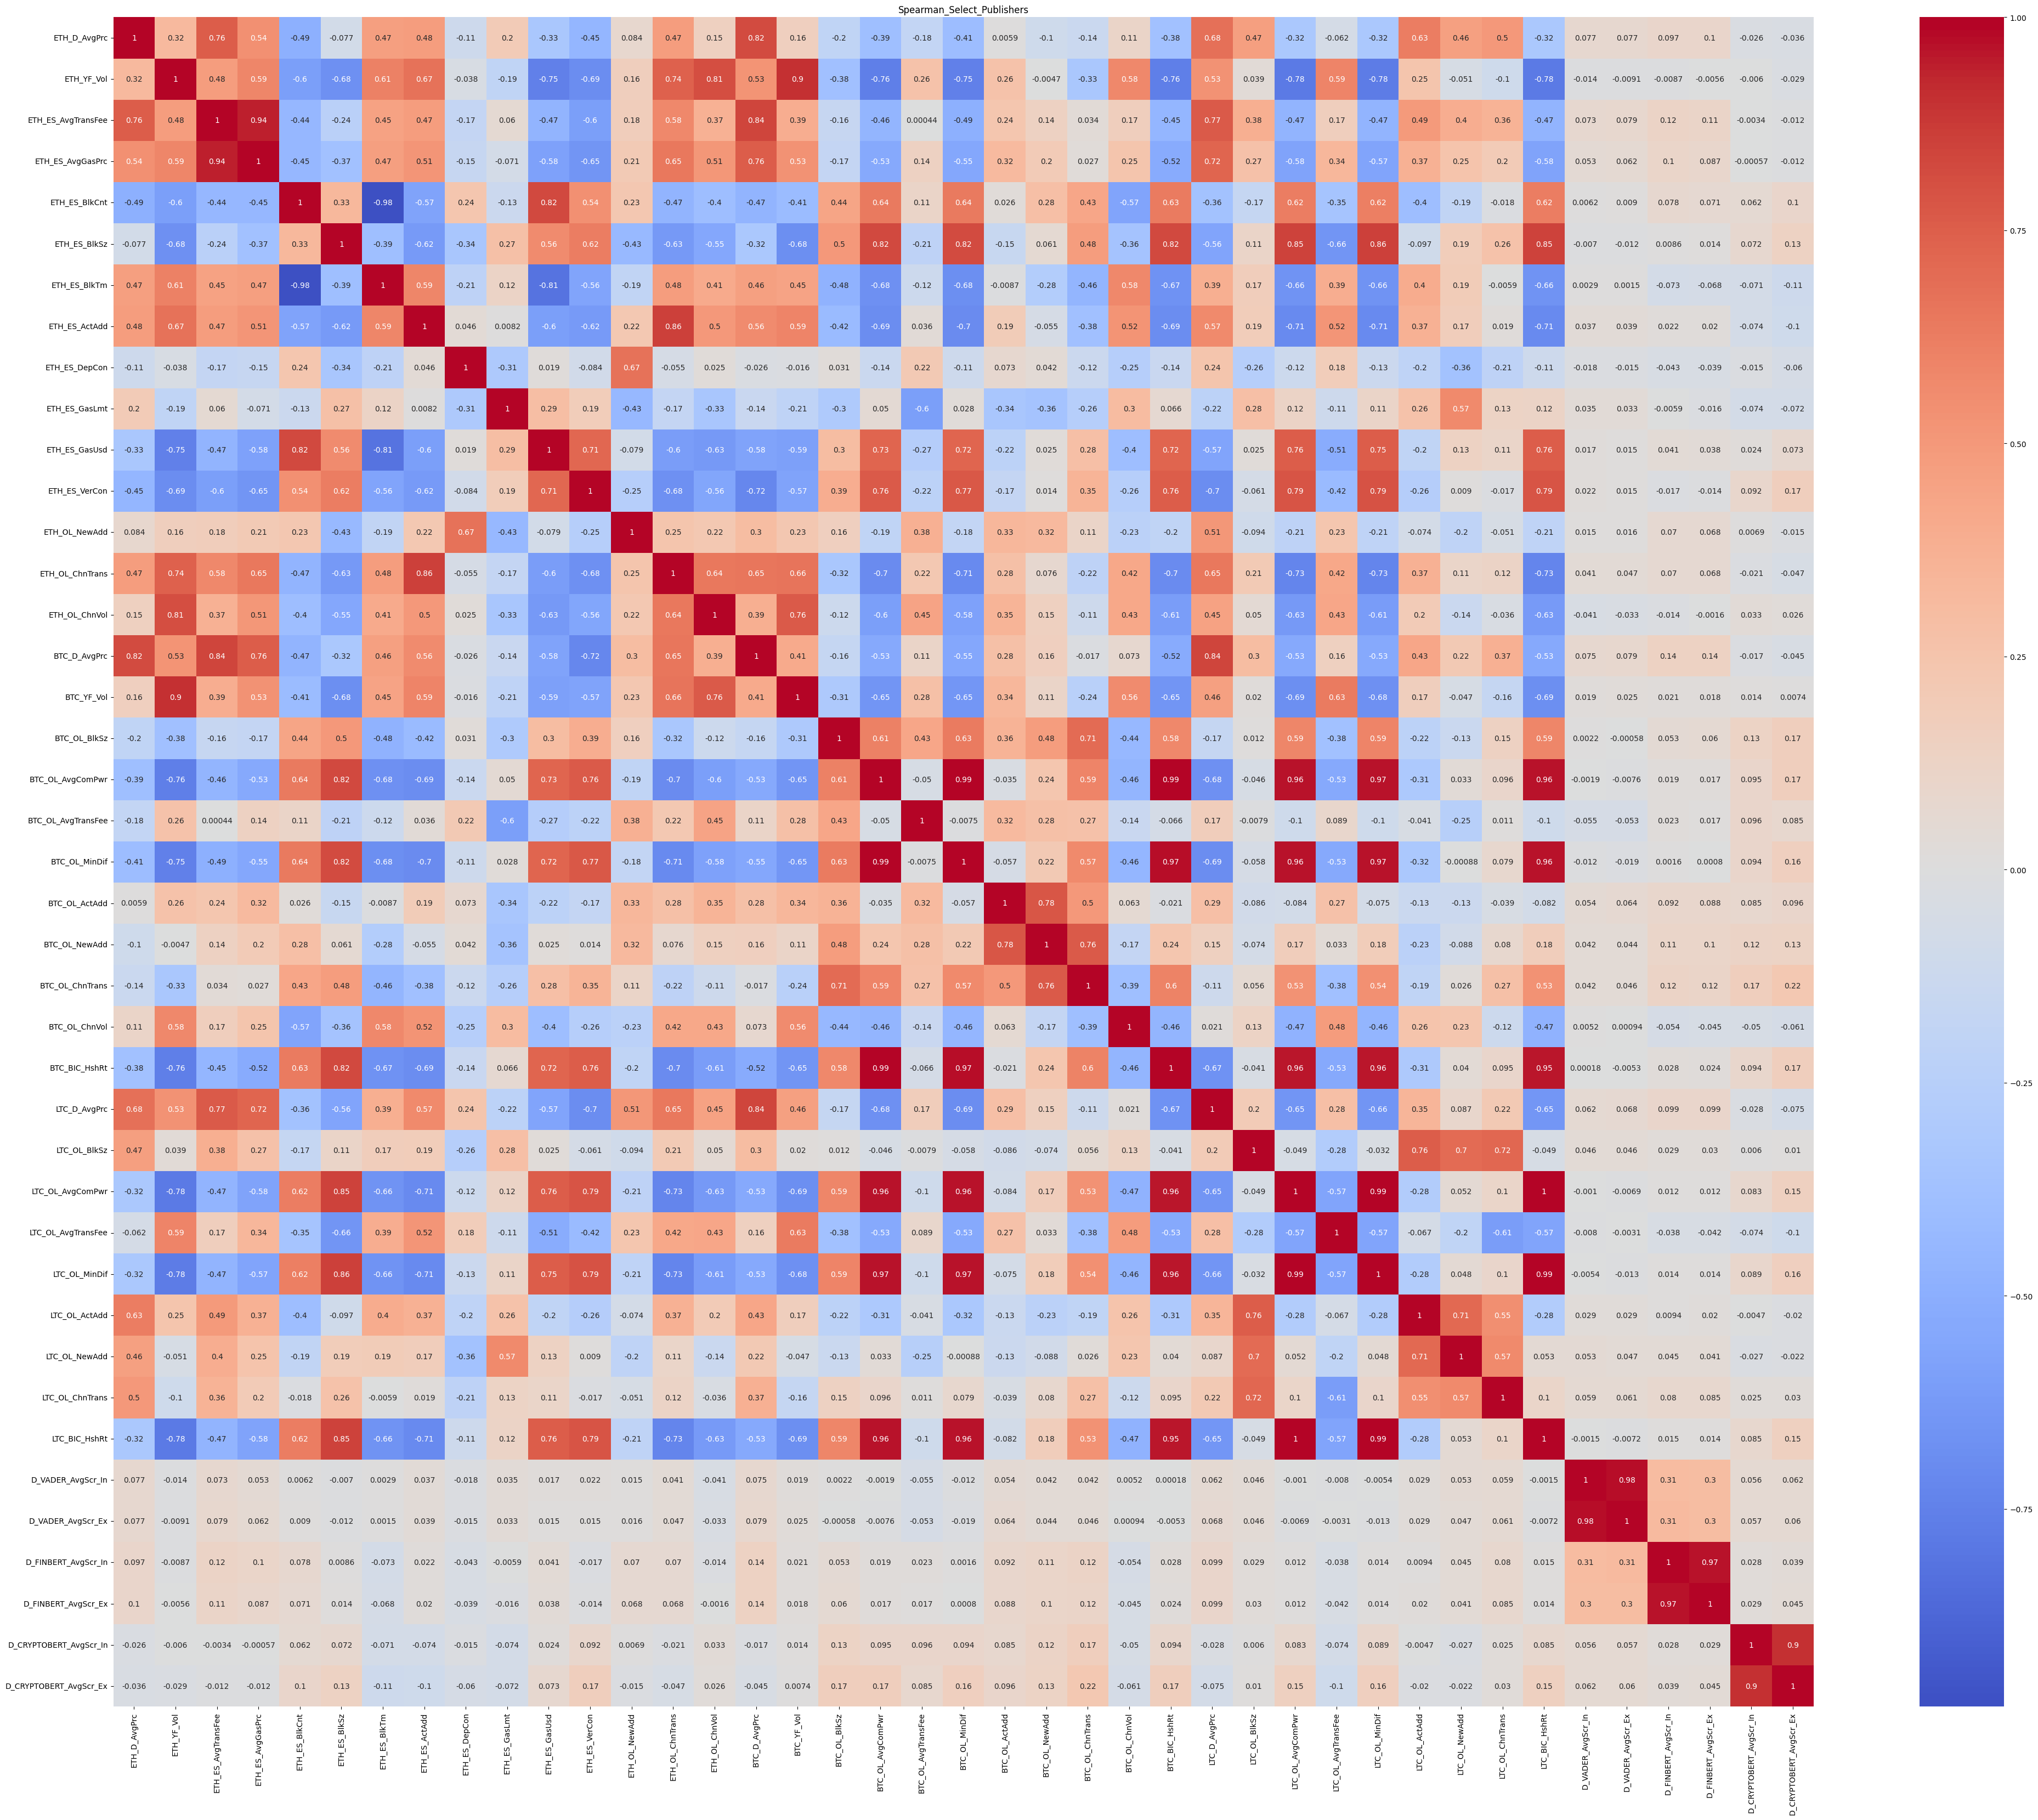

In [20]:
plotter.plot_correlation_matrix(DL.final_data, method="spearman", figsize=(50,40), title="Spearman_Select_Publishers")

In [21]:
plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\correlation_matrix")

### f_regression

In [64]:
train, test = DL.split_data(split_size=split_size)
features=[col for col in DL.final_data if col != 'ETH_D_AvgPrc']
targets=[col for col in DL.final_data if col == 'ETH_D_AvgPrc']
y_train, x_train = train[targets], train[features]

In [76]:
f_regression_selector = SelectKBest(score_func=f_regression, k=15)
f_regression = f_regression_selector.fit_transform(x_train, y_train)

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [77]:
x_train.columns[f_regression_selector.get_support()]

Index(['ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc', 'ETH_ES_ActAdd',
       'ETH_ES_VerCon', 'ETH_OL_ChnTrans', 'BTC_D_AvgPrc', 'BTC_OL_AvgComPwr',
       'BTC_OL_MinDif', 'BTC_BIC_HshRt', 'LTC_D_AvgPrc', 'LTC_OL_AvgComPwr',
       'LTC_OL_MinDif', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd', 'LTC_BIC_HshRt'],
      dtype='object')

### mutual_info_regression

#### RFE

In [69]:
mi_scores = mutual_info_regression(x_train, y_train)
mi_df = pd.DataFrame({'Feature': x_train.columns, 'MI Score': mi_scores})
mi_df.sort_values(by='MI Score', ascending=False).head(15)

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Feature,MI Score
14,BTC_D_AvgPrc,1.741634
19,BTC_OL_MinDif,1.510596
25,LTC_D_AvgPrc,1.335016
29,LTC_OL_MinDif,1.219599
17,BTC_OL_AvgComPwr,1.154428
9,ETH_ES_GasUsd,0.915045
27,LTC_OL_AvgComPwr,0.886157
33,LTC_BIC_HshRt,0.844124
4,ETH_ES_BlkSz,0.732537
1,ETH_ES_AvgTransFee,0.708130


In [82]:
model = XGBRegressor(random_state=42)
rfe = RFE(estimator=model, n_features_to_select=9)
rfe.fit(x_train, y_train)
selected_features = x_train.columns[rfe.support_]
ranking = pd.DataFrame({'Feature': x_train.columns, 'Rank': rfe.ranking_})
print("Top selected features:", selected_features.tolist())
print(ranking.sort_values(by="Rank"))

Top selected features: ['ETH_ES_AvgTransFee', 'ETH_ES_BlkSz', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'BTC_D_AvgPrc', 'BTC_OL_AvgTransFee', 'BTC_OL_MinDif', 'LTC_D_AvgPrc', 'LTC_OL_AvgComPwr']
                   Feature  Rank
19           BTC_OL_MinDif     1
25            LTC_D_AvgPrc     1
18      BTC_OL_AvgTransFee     1
27        LTC_OL_AvgComPwr     1
9            ETH_ES_GasUsd     1
8            ETH_ES_GasLmt     1
14            BTC_D_AvgPrc     1
4             ETH_ES_BlkSz     1
1       ETH_ES_AvgTransFee     1
29           LTC_OL_MinDif     2
17        BTC_OL_AvgComPwr     3
11           ETH_OL_NewAdd     4
20           BTC_OL_ActAdd     5
33           LTC_BIC_HshRt     6
5             ETH_ES_BlkTm     7
26            LTC_OL_BlkSz     8
23           BTC_OL_ChnVol     9
36     D_FINBERT_AvgScr_In    10
34       D_VADER_AvgScr_In    11
15              BTC_YF_Vol    12
31           LTC_OL_NewAdd    13
28      LTC_OL_AvgTransFee    14
21           BTC_OL_NewAdd    15
6            ETH_ES_A

In [92]:
model = Lasso(random_state=42, alpha=50, max_iter=10000)
rfe = RFE(estimator=model, n_features_to_select=9)
rfe.fit(x_train, y_train)
selected_features = x_train.columns[rfe.support_]
ranking = pd.DataFrame({'Feature': x_train.columns, 'Rank': rfe.ranking_})
print("Top selected features:", selected_features.tolist())
print(ranking.sort_values(by="Rank"))

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.273e+07, tolerance: 7.827e+04
  model = cd_fast.enet_coordinate_descent(
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.273e+07, tolerance: 7.827e+04
  model = cd_fast.enet_coordinate_descent(
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

Top selected features: ['ETH_ES_AvgTransFee', 'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_VerCon', 'BTC_D_AvgPrc', 'BTC_OL_NewAdd', 'LTC_D_AvgPrc', 'LTC_OL_AvgComPwr', 'LTC_OL_NewAdd']
                   Feature  Rank
25            LTC_D_AvgPrc     1
1       ETH_ES_AvgTransFee     1
3            ETH_ES_BlkCnt     1
4             ETH_ES_BlkSz     1
21           BTC_OL_NewAdd     1
27        LTC_OL_AvgComPwr     1
10           ETH_ES_VerCon     1
31           LTC_OL_NewAdd     1
14            BTC_D_AvgPrc     1
32         LTC_OL_ChnTrans     2
6            ETH_ES_ActAdd     3
22         BTC_OL_ChnTrans     4
30           LTC_OL_ActAdd     5
12         ETH_OL_ChnTrans     6
20           BTC_OL_ActAdd     7
7            ETH_ES_DepCon     8
8            ETH_ES_GasLmt     9
16            BTC_OL_BlkSz    10
11           ETH_OL_NewAdd    11
23           BTC_OL_ChnVol    12
13           ETH_OL_ChnVol    13
9            ETH_ES_GasUsd    14
0               ETH_YF_Vol    15
2         ETH_ES_AvgGasPrc

#### Forward addition

In [84]:
model = XGBRegressor(random_state=42)
SFS_forward = SequentialFeatureSelector(estimator=model, n_features_to_select=9)
SFS_forward.fit(x_train, y_train)
selected_features = x_train.columns[SFS_forward.support_]
print("Top selected features:", selected_features.tolist())

Top selected features: ['ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc', 'ETH_ES_BlkTm', 'ETH_ES_GasUsd', 'BTC_D_AvgPrc', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd', 'D_CRYPTOBERT_AvgScr_Ex']


#### Backward Elimination

In [85]:
model = XGBRegressor(random_state=42)
SFS_backward = SequentialFeatureSelector(estimator=model, n_features_to_select=9, direction="backward")
SFS_backward.fit(x_train, y_train)
selected_features = x_train.columns[SFS_backward.support_]
print("Top selected features:", selected_features.tolist())

KeyboardInterrupt: 